In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,roc_curve,accuracy_score,classification_report,recall_score,precision_score,f1_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
import sqlite3

In [2]:
conn = sqlite3.connect("Classification.db")

In [3]:
df = pd.read_sql_query("SELECT * FROM fraud_detection",conn)

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
#find the missing values
df.isna().sum()

step                   0
type              203603
amount                 0
nameOrig          203603
oldbalanceOrg          0
newbalanceOrig    267230
nameDest               0
oldbalanceDest    203603
newbalanceDest         0
isFraud                0
isFlaggedFraud         0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
#know the no of unique values in each column
df.nunique()

step                  743
type                    5
amount            5316900
nameOrig          6150287
oldbalanceOrg     1845844
newbalanceOrig    2572469
nameDest          2722362
oldbalanceDest    3500223
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64

In [10]:
#missing value imputation
# categorical
df['type'] = df['type'].fillna('UNKNOWN')
df['nameOrig'] = df['nameOrig'].fillna('MISSING_SENDER')

# numerical
for col in ['newbalanceOrig', 'oldbalanceDest']:
    df[f'{col}_missing'] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(df[col].median())

In [11]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,newbalanceOrig_missing,oldbalanceDest_missing
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0,0


In [12]:
df.isnull().sum()

step                      0
type                      0
amount                    0
nameOrig                  0
oldbalanceOrg             0
newbalanceOrig            0
nameDest                  0
oldbalanceDest            0
newbalanceDest            0
isFraud                   0
isFlaggedFraud            0
newbalanceOrig_missing    0
oldbalanceDest_missing    0
dtype: int64

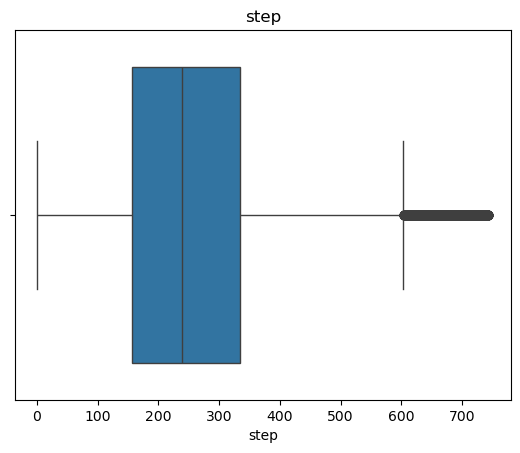

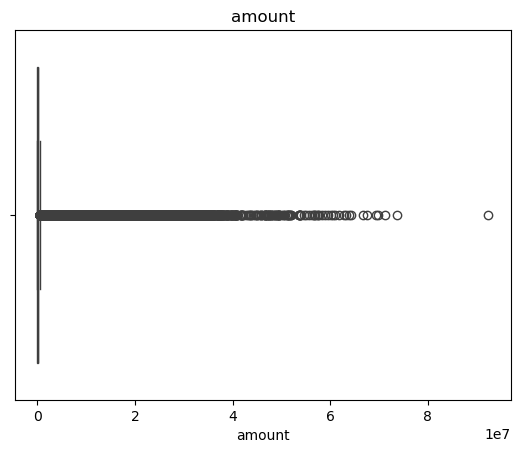

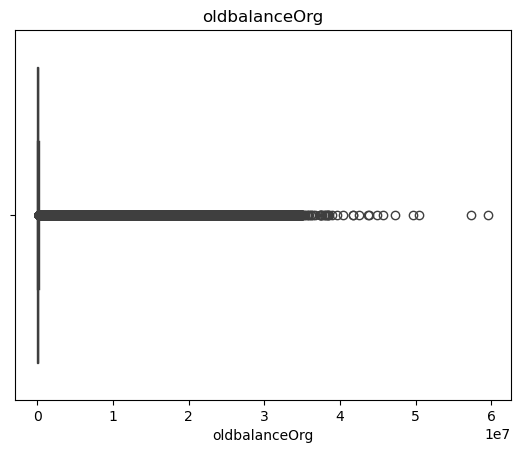

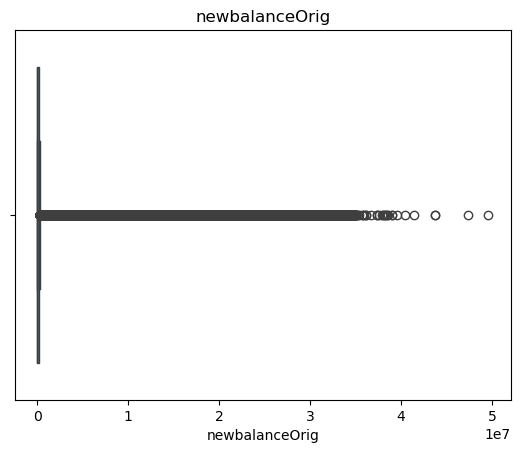

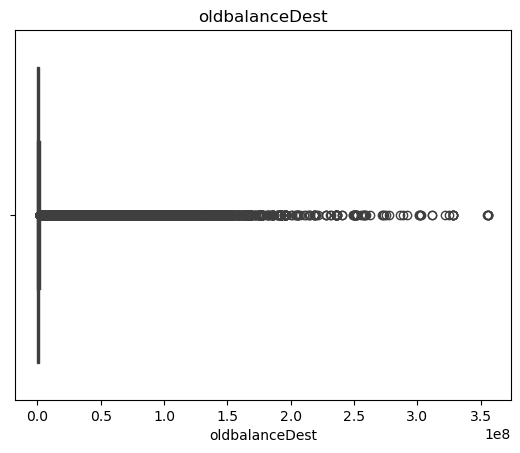

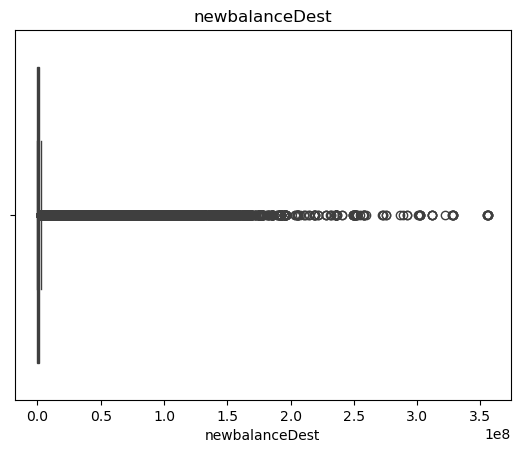

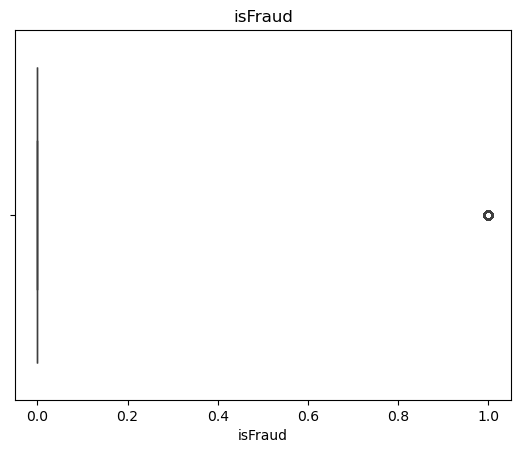

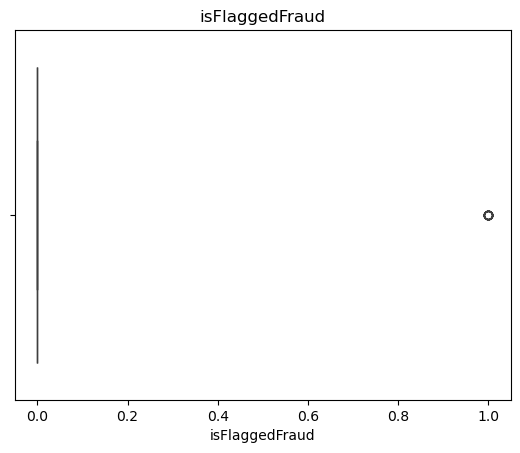

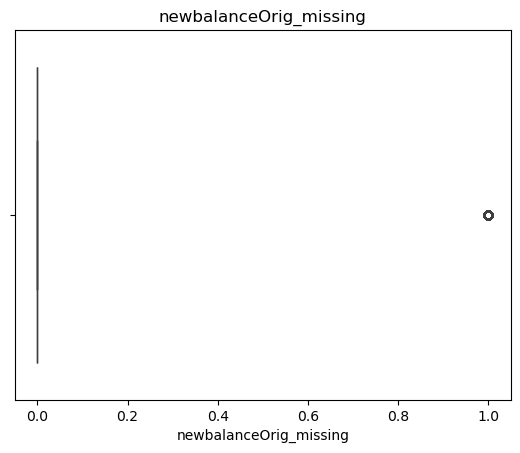

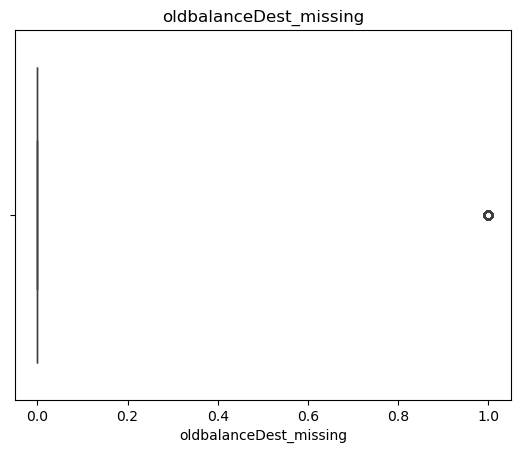

In [13]:
#see if outliers exist in numerical columns
for col in df.select_dtypes(include = ['number']):
    plt.figure()
    sns.boxplot( x = df[col] )
    plt.title(col)
    plt.show()

In [14]:
#we cannot remove outliers as removing them means we wont be able to detect big fraudulent transactions
#Hence we will apply log transform as numbers are highly rightly skewed
#IN this dataset as we are not removing outliers, we will go with Random forest first and XGBoost later


In [15]:
#Apply log transform on the numerical columns
for col in df.select_dtypes(include = ['number']):
    if col != 'isFraud':
        df[col] = np.log1p(df[col])

In [16]:
#Checking the no of unique values in categorical columns
df[['type', 'nameOrig', 'nameDest']].nunique()

type              6
nameOrig    6150288
nameDest    2722362
dtype: int64

In [17]:
#Dropping nameOrig and nameDest as these have millions of unique values and these are basically ids and cannot be used to train the models
df = df.drop(['nameOrig','nameDest'],axis = 1)
#applying one hot encoding to type
df = pd.get_dummies(
    df,
    columns=['type'],
    drop_first=True,
    dtype=int
)

In [18]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,newbalanceOrig_missing,oldbalanceDest_missing,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,type_UNKNOWN
0,0.693147,9.194276,12.044359,11.984786,0.000000,0.0,0,0.0,0.0,0.0,0,0,1,0,0
1,0.693147,7.531166,9.964112,9.872292,0.000000,0.0,0,0.0,0.0,0.0,0,0,1,0,0
2,0.693147,5.204007,5.204007,0.000000,0.000000,0.0,1,0.0,0.0,0.0,0,0,0,1,0
3,0.693147,5.204007,5.204007,0.000000,9.960954,0.0,1,0.0,0.0,0.0,1,0,0,0,0
4,0.693147,9.364703,10.634773,10.305174,0.000000,0.0,0,0.0,0.0,0.0,0,0,1,0,0


In [19]:
#train 4 million, test 1 million and production 1 million
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = df_shuffled.iloc[:4_000_000]
test_df  = df_shuffled.iloc[4_000_000:5_000_000]
prod_df  = df_shuffled.iloc[5_000_000:]

In [6]:
train_df.to_csv("train_sample.csv",index = False)
test_df.to_csv("test.csv",index = False)
prod_df.to_csv("production.csv",index = False)

In [20]:
YTrain = train_df['isFraud']
XTrain = train_df.drop(columns = ['isFraud'])
YTest = test_df['isFraud']
XTest = test_df.drop(columns = ['isFraud'])
YProd = prod_df['isFraud']
XProd = prod_df['isFraud']

In [104]:
#since in the problem statement it is not mentioned that which evaluation parameter to be prioritized,
#we take recall as the parameter or importance as if the output is a fraud transaction,and if it is predicted as non fraud,
#it will affect the business alot
#So we will go with Random Forest first and then try XGBoost
#Taking all 4 million samples for training for RandomForest/XGBoost is too much time consuming. So we will train only 1 million samples on RandomForest/XGBoost
#and then we will see which one will give best results and then compare the LogisticRegression/RandomForest/XGBoost results and then select the best model for applying to all samples
#The dataset is highly imbalanced. Only 8213 out of 6354407 data rows are the fraud ones. So it makes a very low 0.129% 
#Now have to apply this logic(out of 1 million samples, selected for training, 0.129% should be Fraud Transactions)

In [21]:
sample_df, _ = train_test_split(
    df,
    train_size=1000000,
    stratify=df['isFraud'],
    random_state=42
)

In [22]:
y = sample_df['isFraud']
X = sample_df.drop('isFraud', axis=1)

In [23]:
from xgboost import XGBClassifier
XTrain_XGB = X
XTest_XGB = XTest
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    random_state=42
)

xgb.fit(XTrain_XGB, y)

y_pred_xgb = xgb.predict(XTest_XGB)

print(classification_report(YTest,y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    998672
           1       0.97      0.81      0.88      1328

    accuracy                           1.00   1000000
   macro avg       0.98      0.90      0.94   1000000
weighted avg       1.00      1.00      1.00   1000000



In [25]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    tree_method='hist',
    eval_metric='logloss',
    random_state=42
)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5]
}
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)
search.fit(XTrain_XGB, y)
print(search.best_params_)
print(search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.3, 'colsample_bytree': 0.6}
0.8601032789577854


In [26]:
best_xgb = search.best_estimator_

y_pred = best_xgb.predict(XTest)

print(confusion_matrix(YTest, y_pred))
print(classification_report(YTest, y_pred))

[[998638     34]
 [   266   1062]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    998672
           1       0.97      0.80      0.88      1328

    accuracy                           1.00   1000000
   macro avg       0.98      0.90      0.94   1000000
weighted avg       1.00      1.00      1.00   1000000



In [27]:
y_prob = best_xgb.predict_proba(XTest)[:,1]

In [28]:
print("ROC-AUC:", roc_auc_score(YTest,y_prob))

ROC-AUC: 0.9989952666176828


In [29]:
feature_importance = pd.DataFrame({
    'Feature': XTrain.columns,
    'Importance': best_xgb.feature_importances_
})

feature_importance.sort_values(
    'Importance',
    ascending=False
)

,Feature,Importance
12,type_TRANSFER,0.338617
4,oldbalanceDest,0.180267
9,type_CASH_OUT,0.150025
3,newbalanceOrig,0.082727
1,amount,0.078731
5,newbalanceDest,0.053319
11,type_PAYMENT,0.049525
2,oldbalanceOrg,0.022961
8,oldbalanceDest_missing,0.016800
0,step,0.010444


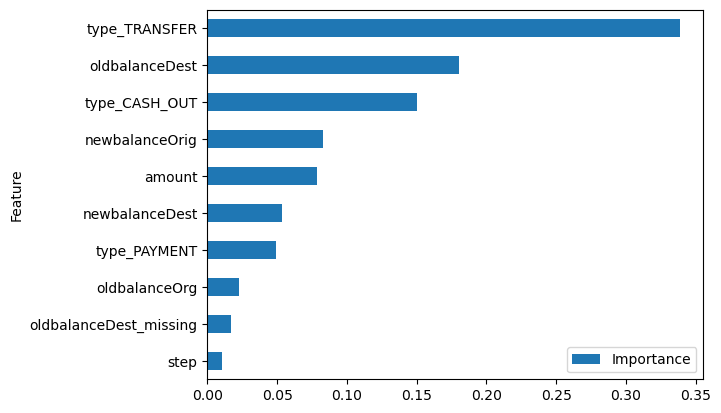

In [30]:
feature_importance.sort_values(
    'Importance',
    ascending=True
).tail(10).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.show()